In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('./dataset/Income1.csv')

In [5]:
data

,Unnamed: 0,Education,Income
0,1,10.000000,26.658839
1,2,10.401338,27.306435
2,3,10.842809,22.132410
3,4,11.244147,21.169841
4,5,11.645485,15.192634
5,6,12.086957,26.398951
6,7,12.488294,17.435307
7,8,12.889632,25.507885
8,9,13.290970,36.884595
9,10,13.732441,39.666109


Text(0, 0.5, 'Income')

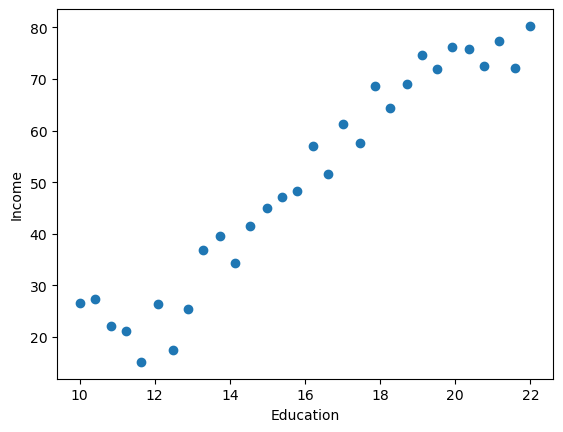

In [6]:
plt.scatter(data.Education, data.Income)
plt.xlabel('Education')
plt.ylabel('Income')

In [7]:
# wx + b

In [8]:
# 分解写法
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [9]:
learning_rate = 0.001

In [8]:
X = torch.from_numpy(data.Education.values.reshape(-1, 1)).type(torch.FloatTensor)
Y = torch.from_numpy(data.Income.values.reshape(-1, 1)).type(torch.FloatTensor)

In [11]:
# 定义训练过程
for epoch in range(5000):
    for x, y in zip(X, Y):
        y_pred = torch.matmul(x, w) + b
        # 损失函数
        loss = (y - y_pred).pow(2).sum()

        # pytorch对一个变量多次求导, 求导的结果会累加起来
        if w.grad is not None:
            # 重置w的导数
            w.grad.data.zero_()
        if b.grad is not None:
            b.grad.data.zero_()
        
        # 反向传播, 即求w,b的导数
        loss.backward()

        # 更新w,b
        with torch.no_grad():
            w.data -= w.grad.data * learning_rate
            b.data -= b.grad.data * learning_rate



In [12]:
w


tensor([5.1266], requires_grad=True)

In [13]:
b

tensor([-32.6959], requires_grad=True)

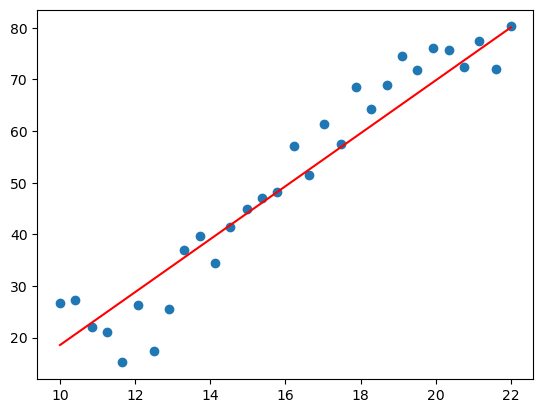

In [15]:
plt.scatter(data.Education, data.Income)
plt.plot(X.numpy(), (torch.matmul(X, w) + b).data.numpy(), c='r')

### 1 pytorch实现线性回归--封装写法

In [4]:
from torch import nn

In [5]:
# 和tensorflow中的Dense一个意思
# wx + b
model = nn.Linear(1, 1)

In [6]:
model

Linear(in_features=1, out_features=1, bias=True)

In [7]:
# 定义损失函数
loss_fn = nn.MSELoss()

In [10]:
# 即w
model.parameters()

<generator object Module.parameters at 0x000001AD64813A00>

In [12]:
# 定义优化器
# 优化器的第一个参数必须是要更新的模型中的参数
opt = torch.optim.SGD(model.parameters(), lr=0.001)

In [13]:
# 训练
for epoch in range(5000):
    for x, y in zip(X, Y):
        y_pred = model(x)
        loss = loss_fn(y, y_pred)
        # 梯度清零操作
        opt.zero_grad()
        loss.backward()
        # 更新操作
        opt.step()

In [14]:
# w
model.weight

Parameter containing:
tensor([[5.1267]], requires_grad=True)

In [15]:
# b
model.bias

Parameter containing:
tensor([-32.6971], requires_grad=True)